# Vision Editor – Advanced Image Enhancement & Analysis

## Objective
This project aims to:
- Apply image processing techniques
- Visualize histograms
- Evaluate impact on CV accuracy

## Tools
- OpenCV
- NumPy
- Matplotlib
- Tkinter (for GUI part)

In [1]:
import matplotlib.pylab as plt
from PIL import Image
import cv2
import numpy as np

- we are gitting the img frist

In [2]:
img = cv2.imread("im.jpg")
r_img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

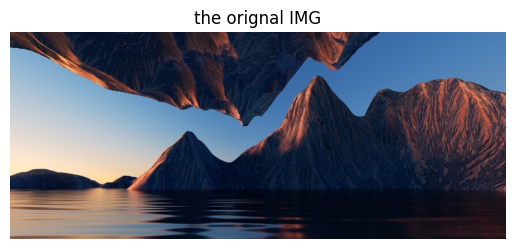

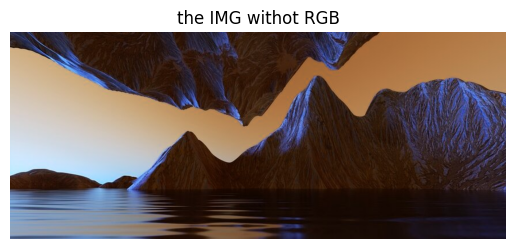

In [3]:
plt.imshow(r_img)
plt.title("the orignal IMG")
plt.axis("off")
plt.show()



plt.imshow(img)
plt.title("the IMG withot RGB")
plt.axis('off')
plt.show()

- 1 - **Brightness & Contrast**

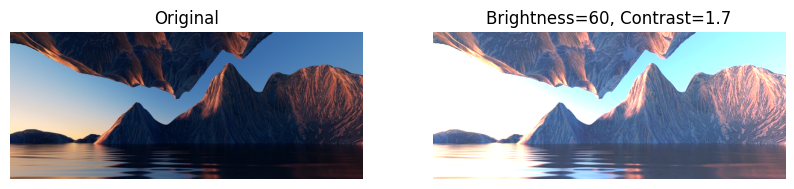

In [13]:
br_img = cv2.convertScaleAbs(r_img,alpha=1.7,beta=60)



plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(r_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(br_img)
plt.title("Brightness=60, Contrast=1.7")
plt.axis("off")

plt.show()


- 2 - **Zooming**

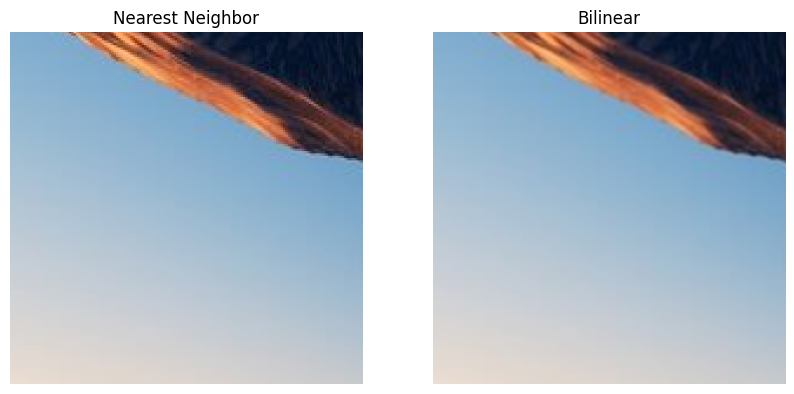

In [19]:
h, w = r_img.shape[:2]

zoom_nn = cv2.resize(r_img, (w*2, h*2), interpolation=cv2.INTER_NEAREST)
zoom_bl = cv2.resize(r_img, (w*2, h*2), interpolation=cv2.INTER_LINEAR)

patch_nn = zoom_nn[100:400, 100:400]
patch_bl = zoom_bl[100:400, 100:400]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(patch_nn)
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(patch_bl)
plt.title("Bilinear")
plt.axis("off")

plt.show()

- 3 - **Rotation**

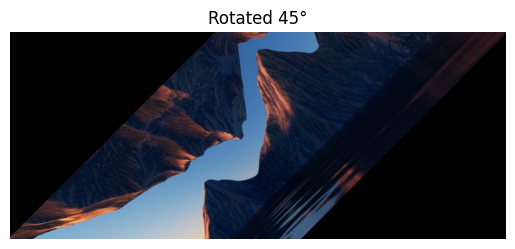

In [22]:
center = (w//2, h//2)

matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(r_img, matrix, (w, h))

plt.imshow(rotated)
plt.title("Rotated 45°")
plt.axis("off")
plt.show()

- 4 - **Histogram Visualization**

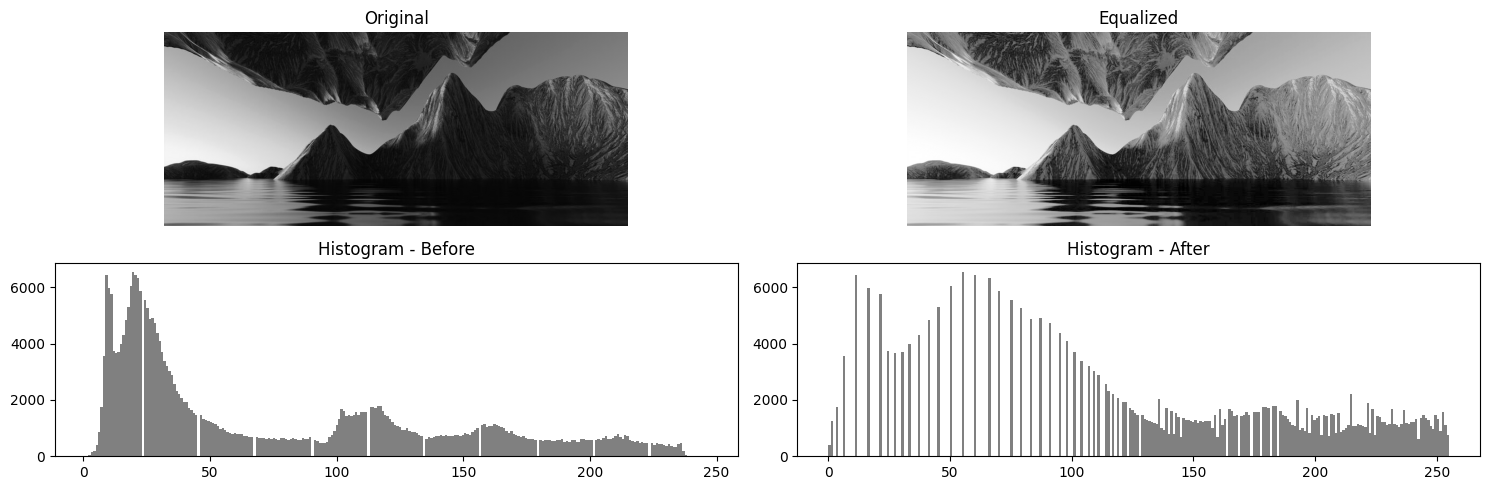

In [29]:
gray = cv2.cvtColor(r_img, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(15,5))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized")
plt.axis("off")

plt.subplot(2,2,3)
plt.hist(gray.ravel(), 256, color='gray')
plt.title("Histogram - Before")

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), 256, color='gray')
plt.title("Histogram - After")

plt.tight_layout()
plt.show()

- 5 - **Gamma correction**

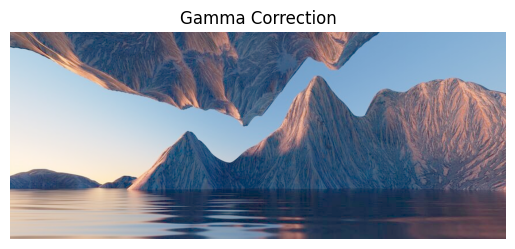

In [32]:
table = np.array([(i/255.0)**0.5 * 255 for i in range(256)]).astype("uint8")
gamma_img = cv2.LUT(r_img, table)

plt.imshow(gamma_img)
plt.title("Gamma Correction")
plt.axis("off")
plt.show()

- 6 - **Gaussian Blur**

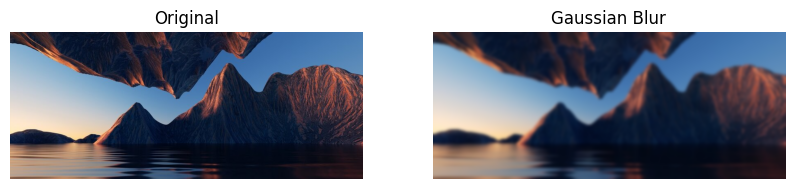

In [37]:
blur = cv2.GaussianBlur(r_img, (21,21), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(r_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

- 7 - **sobal & canny**

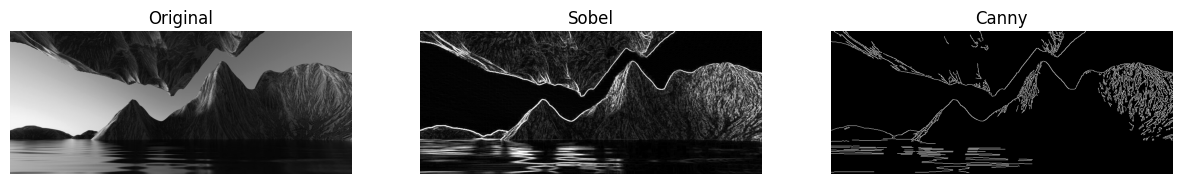

In [ ]:
gray = cv2.cvtColor(r_img, cv2.COLOR_RGB2GRAY)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.uint8(np.clip(cv2.magnitude(sobel_x, sobel_y), 0, 255))

canny = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.show()

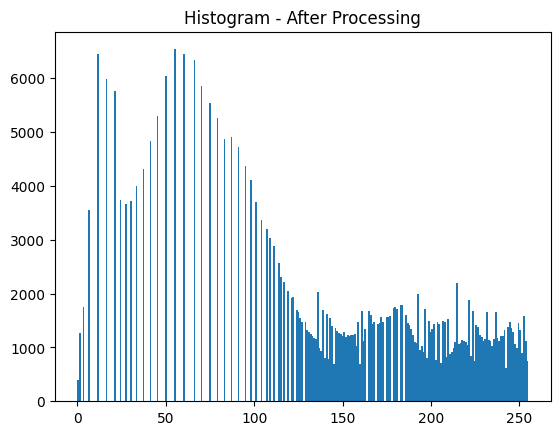

In [10]:
plt.hist(equalized.ravel(),256)
plt.title("Histogram - After Processing")
plt.show()

## - **Detection**

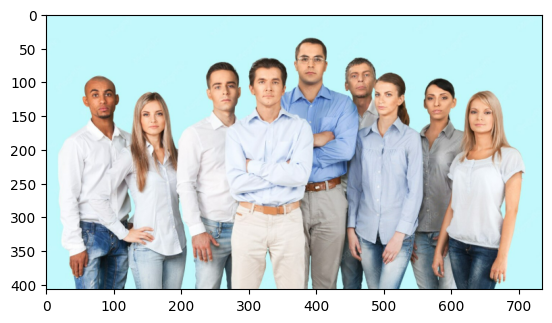

In [11]:
img = cv2.imread("persons.jpg")
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)

In [12]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_faces(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    return len(faces)

In [13]:
original_faces = detect_faces(img)
processed_faces = detect_faces(cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR))

print("Original Faces:", original_faces)
print("Processed Faces:", processed_faces)

Original Faces: 9
Processed Faces: 0


In [14]:
import time

start = time.time()
detect_faces(img)
original_time = time.time() - start

processed_img = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)

start = time.time()
detect_faces(processed_img)
processed_time = time.time() - start

print("Original Time:", original_time)
print("Processed Time:", processed_time)

Original Time: 0.09054207801818848
Processed Time: 0.03802776336669922


In [15]:
import pandas as pd

df = pd.DataFrame({
    "Case": ["Original", "Processed"],
    "Faces Detected": [original_faces, processed_faces],
    "Inference Time": [original_time, processed_time]
})

df

,Case,Faces Detected,Inference Time
0,Original,9,0.090542
1,Processed,0,0.038028
